In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random as rdm
import numpy as np

### Ejercicio 1

Considere una red regular en anillo con N=100 nodos, donde cada nodo está conectado con sus k = 4 vecinos más cercanos.

Genere la red.

Dibuje la red obtenida.

Calcule el coeficiente de clustering promedio.

Calcule la longitud media de camino entre nodos.

Interprete los resultados.

Clustering promedio 0.5
Longitud promedio de camino mas corto 12.879


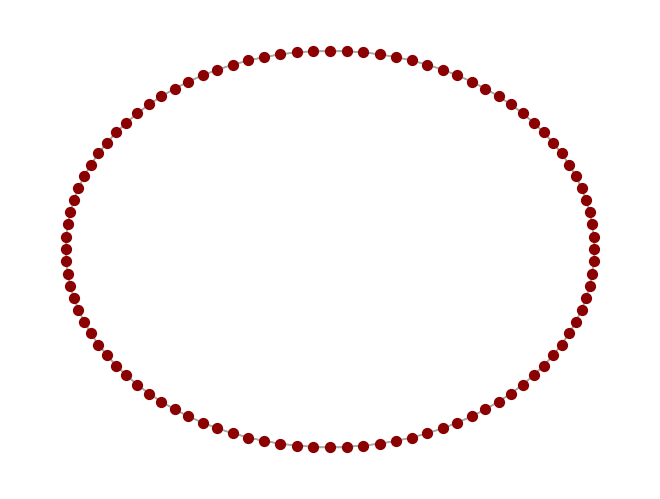

In [11]:
N=100; k=4; p=0;
G=nx.watts_strogatz_graph(N, k, p)
pos=nx.circular_layout(G)
nx.draw(G,pos,node_size=50,node_color="darkred",edge_color="darkgray")
print(fr"Clustering promedio {nx.average_clustering(G)}")
print(fr"Longitud promedio de camino mas corto {round(nx.average_shortest_path_length(G),3)}")

¿Cómo describiría la estructura local y global de esta red?

La estructura global y local es la misma, cada nodo es igual al anterior y tiene 4 vecinos, entonces parece un circulo.

### Ejercio 2

Considere redes de Watts–Strogatz con N=100 k = 4 y distintos valores de la probabilidad de reconexión $\beta=0,0.01,0.05,0.1,0.5,1$.
 

Para cada valor de $\beta$:

- Genere una realización de la red.
- Calcule el coeficiente de clustering promedio.
- Calcule la longitud media de camino.
- Organice los resultados en una tabla.


p=0 | Clusterirng Promedio 0.5 | Longitud media 12.879   
p=0.01 | Clusterirng Promedio 0.5 | Longitud media 12.879   
p=0.05 | Clusterirng Promedio 0.449 | Longitud media 6.395   
p=0.1 | Clusterirng Promedio 0.365 | Longitud media 4.669   
p=0.5 | Clusterirng Promedio 0.125 | Longitud media 3.69   
p=1 | Clusterirng Promedio 0.021 | Longitud media 3.43   


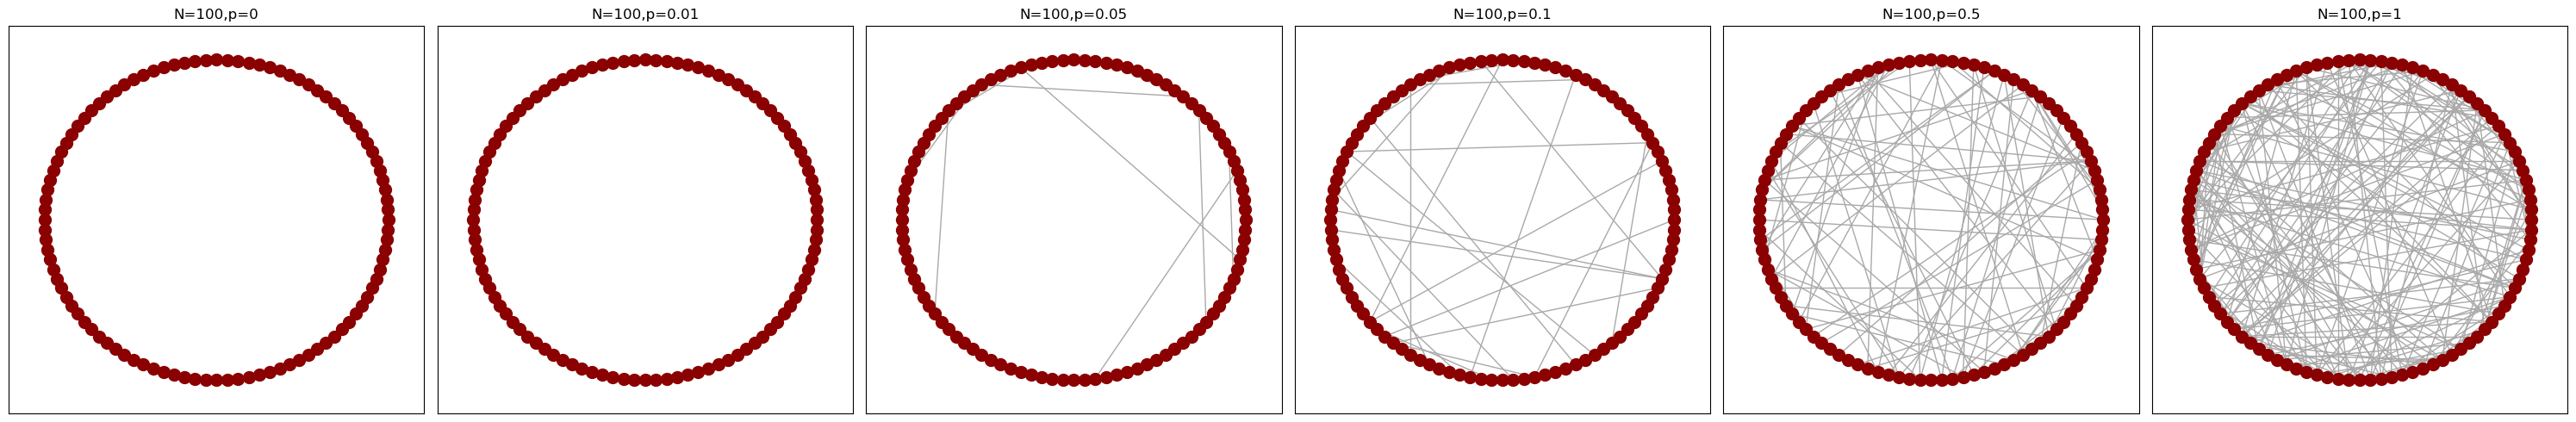

In [28]:
N=100;k=4;β=[0,0.01,0.05,0.1,0.5,1];
grafos=[]
for p in β:
    G=nx.watts_strogatz_graph(N, k, p)
    grafos.append(G)
    print(fr"p={p} | Clusterirng Promedio {round(nx.average_clustering(G),3)} | Longitud media {round(nx.average_shortest_path_length(G),3)}   ")

n_real=len(grafos)
fig,axes=plt.subplots(1,n_real, figsize=(5*n_real,5))

for k, ax, G in zip(range(len(β)),axes,grafos):
    pos=nx.circular_layout(G)
    p=β[k]
    L=G.number_of_edges()
    nx.draw_networkx_nodes(G,pos,ax=ax,node_size=100,node_color='darkred')
    nx.draw_networkx_edges(G,pos,ax=ax,node_size=100,edge_color='darkgray',width=1)
    ax.set_title(f"N={N},p={round(p, 3)}",fontsize=12)
plt.tight_layout()
plt.show()

¿Cómo cambian el clustering y la longitud media de camino al aumentar β?

La longitud media y el clustering decrecen cuando aumenta $\beta$.

### Ejercicio 3
 
Considere el modelo de Watts–Strogatz con $N = 100$ y $k=4$.

- Para varios valores de $\beta$,calcule: $C(\beta)$,$L(\beta)$.

- Normalice estos valores respecto al caso regular $\beta=0$
 
 
- Grafique ambas cantidades en función de $\beta$
 .
- Identifique el rango de valores de $\beta$ en el que la red presenta efecto de mundo pequeño

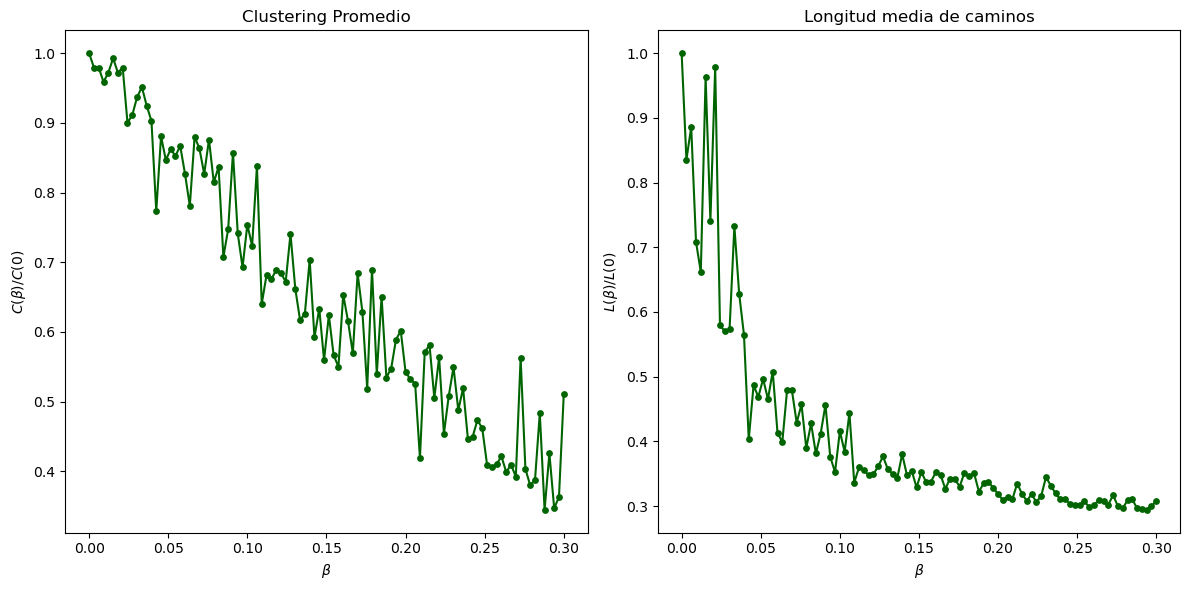

In [37]:
N=100;k=4; I=np.linspace(0,0.3,100)
cs=[]
ls=[]
c=nx.average_clustering(nx.watts_strogatz_graph(100, 4, 0))
l=nx.average_shortest_path_length(nx.watts_strogatz_graph(100, 4, 0))

for p in I:
    G=nx.watts_strogatz_graph(N,k,p)
    cs.append(nx.average_clustering(G)/c)
    ls.append(nx.average_shortest_path_length(G)/l)

a=[cs,ls]

titulos=["Clustering Promedio","Longitud media de caminos"]
ylab=[fr"$C(\beta)/C(0)$",fr"$L(\beta)/L(0)$"]
fig,axes=plt.subplots(1,2, figsize=(6*2,6))
for a,ax,title,lav in zip(a,axes,titulos,ylab):
    ax.scatter(I, a,s=15,color="darkgreen")
    ax.plot(I,a,color="darkgreen")
    ax.set_xlabel(fr"$\beta$")
    ax.set_ylabel(lav)
    ax.set_title(title)
    
plt.tight_layout()
plt.show()

¿Por qué se dice que una red está en el régimen de mundo pequeño cuando la longitud media de camino disminuye mucho, pero el clustering permanece relativamente alto?

Por que ese es el efecto que se encuentra en redes reales de mundo pequeño.

### Ejercicio 4

Considere una red de Watts–Strogatz con N = 100, k=4 y un valor pequeño de $\beta$, y compárela con una red de Erdős–Rényi con número de nodos similar y grado promedio comparable.

- Genere ambas redes.
- Calcule en cada caso:
- el coeficiente de clustering promedio,
- la longitud media de camino.
- Dibuje ambas redes.
- Compare los resultados.

0.31999999999999984
Erdos-Renyi p=0.041| Grado pormedio 3.68 | Clustering promedio 0.038 | Longitud media 3.443
Watts Strogatz| Grado pormedio 4.0 | Clustering promedio 0.443 | Longitud media 6.111


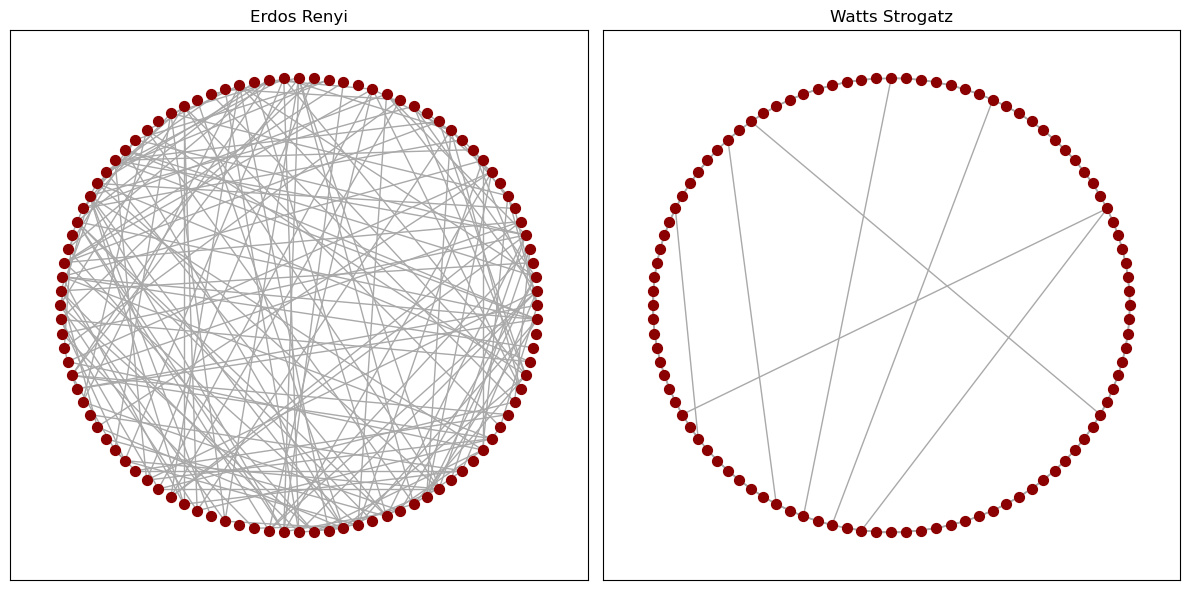

In [150]:
N=100; k=4; β=0.05; p=(k+β/2)/(N-1) 
E=nx.erdos_renyi_graph(N, p)

largnodes = max(nx.connected_components(E), key=len)
larg = E.subgraph(largnodes).copy()


W=nx.watts_strogatz_graph(N,k,β)
Eavg_degree = sum(dict(E.degree()).values()) / E.number_of_nodes()
Wavg_degree = sum(dict(W.degree()).values()) / W.number_of_nodes()
print(fr"{abs(Eavg_degree-Wavg_degree)}")
print(fr"Erdos-Renyi p={round(p,3)}| Grado pormedio {Eavg_degree} | Clustering promedio {round(nx.average_clustering(E),3)} | Longitud media {round(nx.average_shortest_path_length(larg),3)}")
print(fr"Watts Strogatz| Grado pormedio {Wavg_degree} | Clustering promedio {round(nx.average_clustering(W),3)} | Longitud media {round(nx.average_shortest_path_length(W),3)}")

grafos=[E,W]
fig,axes=plt.subplots(1,2, figsize=(6*2,6))
titulos=["Erdos Renyi","Watts Strogatz"]
for ax, G,title in zip(axes,grafos,titulos):
    pos=nx.circular_layout(G)
    nx.draw_networkx_nodes(G,pos,ax=ax,node_size=50,node_color='darkred')
    nx.draw_networkx_edges(G,pos,ax=ax,node_size=50,edge_color='darkgray',width=1)
    ax.set_title(title)

plt.tight_layout()
plt.show()

¿Por qué una red de Watts–Strogatz puede presentar efecto de mundo pequeño de forma más clara que una red de Erdős–Rényi?
Porque al iniciar con nodos adyacentes ya conectados mantiene un clustering mayor y hace que la presencia de una arista extra redusca la longitud del camino minimo mas.